# Notebook for Modeling 
## For Analyzing Bias after Vision Zero

In [140]:
# install packages if necessary
%pip install -r "requirements.txt"

# import relevant packages
import pandas as pd
import geopandas as gpd
import zipfile
from plotnine import *
import numpy as np
from data_functions import load_data

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Load and process data
- Apply any necessary processing steps to the cleaned dataset
- This includes using one-hot encoding to convert categorical data into a binary array, which is necessary since there is no natural ordering between categories

In [141]:
file_path = "data/stops_clean.csv.zip"
stops_df = load_data(file_path)

Unzipped


In [142]:
# transform date and time variable to day of week and time 
stops_df['date'] = pd.to_datetime(stops_df['date'])
stops_df['day_of_week'] = stops_df['date'].dt.day_name()
stops_df['month'] = stops_df['date'].dt.month

# pivot outcomes to one long column
stops_df['outcome'] = np.select(
    [stops_df['arrest_made'] == 1,
     stops_df['citation_issued'] == 1,
     stops_df['warning_issued'] == 1],
    [0, 1, 2],  
    default = 3 # if none of the above 
)
stops_df = stops_df.drop(
    columns=['warning_issued', 'citation_issued', 'arrest_made']
)

# drop other columns not needed for modeling
stops_df = stops_df.drop(
    columns = ['time', 'lat', 'lng', 'pct_over75', 'pct_poc', 'pct_disab']
)

# Create Training, Tuning, Testing Sets
- Using a 75/15/15 split from the complete data

In [143]:
# create separate sets by policy date
pre_policy_df = stops_df[stops_df['date'] < '2014-03-01']
post_policy_df = stops_df[stops_df['date'] >= '2014-03-01']

pre_policy_df = pre_policy_df.drop(columns = ['date'])
post_policy_df = post_policy_df.drop(columns = ['date'])

In [144]:
from sklearn.model_selection import train_test_split

def stratified_split_with_min_epc(df, outcome_col='outcome', epc_col='epc_class', 
                                  train_frac=0.75, val_frac=0.15, test_frac=0.15, random_state=42):
    """
    Splits df into train/val/test with:
    Stratified by outcome
    Ensures EPC classes are present in each set
    """
    
    # Initial train / temp split
    train_df, temp_df = train_test_split(
        df,
        test_size=(1 - train_frac),
        stratify=df[outcome_col],
        random_state=random_state
    )
    
    # Split temp into validation and test
    val_df, test_df = train_test_split(
        temp_df,
        test_size=test_frac / (test_frac + val_frac),  # proportion of temp
        stratify=temp_df[outcome_col],
        random_state=random_state
    )
    
    splits = {'train': train_df, 'val': val_df, 'test': test_df}
    
    # Ensure each EPC class appears in each split
    all_epc_classes = set(df[epc_col])
    
    for split_name, split_df in splits.items():
        missing_epc = all_epc_classes - set(split_df[epc_col])
        for epc in missing_epc:
            # Find a split that contains this EPC class and take one row
            for other_name, other_df in splits.items():
                if other_name == split_name:
                    continue
                if epc in set(other_df[epc_col]):
                    row_to_move = other_df[other_df[epc_col] == epc].iloc[0]
                    split_df = pd.concat([split_df, pd.DataFrame([row_to_move])], ignore_index=True)
                    splits[other_name] = other_df.drop(row_to_move.name)
                    break
        splits[split_name] = split_df
    
    return splits['train'], splits['val'], splits['test']

In [145]:
# get training, validation, testing sets
train_pre, val_pre, test_pre = stratified_split_with_min_epc(pre_policy_df, outcome_col='outcome')
train_post, val_post, test_post = stratified_split_with_min_epc(post_policy_df, outcome_col='outcome')

# create dummy variables for categorical variables
train_pre = pd.get_dummies(train_pre, columns=['month', 'day_of_week', 'light_condition', 'subject_race', 'subject_sex', 'district', 'epc_class'])
val_pre = pd.get_dummies(val_pre, columns=['month', 'day_of_week', 'light_condition', 'subject_race', 'subject_sex', 'district', 'epc_class'])
test_pre = pd.get_dummies(test_pre, columns=['month', 'day_of_week', 'light_condition', 'subject_race', 'subject_sex', 'district', 'epc_class'])

X_train_pre = train_pre.drop(columns=['outcome'])
y_train_pre = train_pre['outcome']
X_val_pre = val_pre.drop(columns=['outcome'])
y_val_pre = val_pre['outcome']
X_test_pre = test_pre.drop(columns=['outcome'])
y_test_pre = test_pre['outcome']

train_post = pd.get_dummies(train_post, columns=['month', 'day_of_week', 'light_condition', 'subject_race', 'subject_sex', 'district', 'epc_class'])
val_post = pd.get_dummies(val_post, columns=['month', 'day_of_week', 'light_condition', 'subject_race', 'subject_sex', 'district', 'epc_class'])
test_post = pd.get_dummies(test_post, columns=['month', 'day_of_week', 'light_condition', 'subject_race', 'subject_sex', 'district', 'epc_class'])

X_train_post = train_post.drop(columns=['outcome'])
y_train_post = train_post['outcome']
X_val_post = val_post.drop(columns=['outcome'])
y_val_post = val_post['outcome']
X_test_post = test_post.drop(columns=['outcome'])
y_test_post = test_post['outcome']

## Fit Model for Pre-Policy Data

In [154]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

# fit models with training data and then evaluate with validation data
le = LabelEncoder()
y_train_pre_enc = le.fit_transform(y_train_pre)
num_classes = len(le.classes_)

# param_grid = {
#     'max_depth': [4, 6, 8],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.7, 0.8, 1.0],
#     'colsample_bytree': [0.7, 0.8, 1.0],
#     'gamma': [0, 0.1, 0.5]
# }

param_grid = {
    'max_depth': [8],
    'learning_rate': [0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'gamma': [0]
}

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    n_estimators=300,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    # f1_macro for imbalanced classes
    scoring='f1_macro', 
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_pre, y_train_pre_enc)

# get best model parameters
best_model = grid_search.best_estimator_
y_val_pre_pred = best_model.predict(X_val_pre)
y_val_pre_pred_labels = le.inverse_transform(y_val_pre_pred)
# print best parameters
best_model.get_params()

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=8, subsample=0.8; total time=  21.9s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=8, subsample=0.8; total time=  21.9s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=8, subsample=0.8; total time=  22.0s


{'objective': 'multi:softprob',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.8,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': 0,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 8,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 300,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 0.8,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None,
 'num_class': 4}

Pre-Policy Test Set Accuracy: 0.8225806451612904


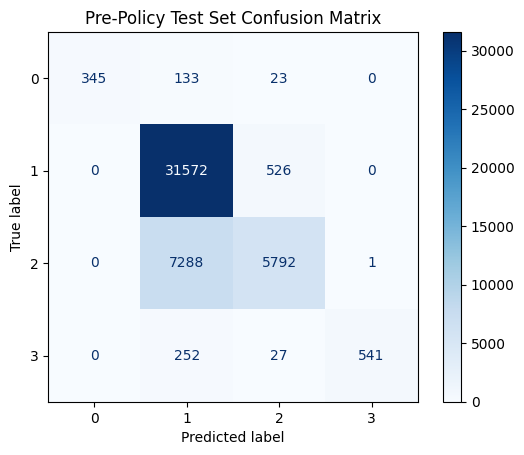

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# get final predictions
test_pre_preds = best_model.predict(X_test_pre)

# Calculate the accuracy score
accuracy = accuracy_score(y_test_pre, test_pre_preds)
print("Pre-Policy Test Set Accuracy:", accuracy)

# get confusion matrix
cm = confusion_matrix(y_test_pre, test_pre_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Pre-Policy Test Set Confusion Matrix")
plt.show()


## Fit Model for Post Policy Data 

In [ ]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

# fit models with training data and then evaluate with validation data
le = LabelEncoder()
y_train_post_enc = le.fit_transform(y_train_post)
num_classes = len(le.classes_)

# param_grid = {
#     'max_depth': [4, 6, 8],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.7, 0.8, 1.0],
#     'colsample_bytree': [0.7, 0.8, 1.0],
#     'gamma': [0, 0.1, 0.5]
# }

param_grid = {
    'max_depth': [8],
    'learning_rate': [0.1],
    'subsample': [0.8],
    'colsample_bytree': [1.0],
    'gamma': [0.5]
}

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    n_estimators=300,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    # f1_macro for imbalanced classes
    scoring='f1_macro', 
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_post, y_train_post_enc)

# get best model parameters
best_model = grid_search.best_estimator_
y_val_post_pred = best_model.predict(X_val_post)
y_val_post_pred_labels = le.inverse_transform(y_val_post_pred)
# print best parameters
best_model.get_params()

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.1, max_depth=8, subsample=1.0; total time=   6.1s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.1, max_depth=8, subsample=1.0; total time=   6.5s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.1, max_depth=8, subsample=0.8; total time=   7.4s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.1, max_depth=8, subsample=1.0; total time=   6.5s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.1, max_depth=8, subsample=0.8; total time=   7.5s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.1, max_depth=8, subsample=0.8; total time=   8.4s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.1, max_depth=8, subsample=0.7; total time=   9.7s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.1, max_depth=8, subsample=0.7; total time=   9.7s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.1, max_depth=8, sub

{'objective': 'multi:softprob',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 1.0,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': 0.5,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 8,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 300,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 0.8,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None,
 'num_class': 4}

Post-Policy Test Set Accuracy: 0.8186862459365541


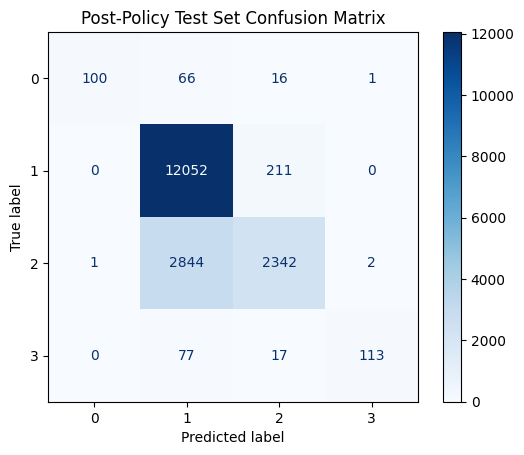

In [ ]:
# get final predictions
test_post_preds = best_model.predict(X_test_post)

# Calculate the accuracy score
accuracy = accuracy_score(y_test_post, test_post_preds)
print("Post-Policy Test Set Accuracy:", accuracy)

# get confusion matrix
cm = confusion_matrix(y_test_post, test_post_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Post-Policy Test Set Confusion Matrix")
plt.show()

## Get SHAP values from model results

In [161]:
import shap

booster = best_model.get_booster()
explainer = shap.TreeExplainer(booster)
# shap_values = explainer.shap_values(X_test_pre)

ValueError: could not convert string to float: '[-1.9181743E0,2.2865853E0,1.4265417E0,-1.7949529E0]'